Modeling the joint probability of seeing the aurora, given the auroral activity and environmental conditions:

I. probability of aurora activity

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import missingno as msno
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc, roc_curve
from sklearn.model_selection import train_test_split, TimeSeriesSplit, StratifiedKFold
from sklearn.utils import resample
from sklearn.ensemble import RandomForestClassifier

In [79]:
df = pd.read_csv("aurora_dataset_clean.csv")
with pd.option_context('display.max_columns', None):
    display(df.head())

,raw_row_num,obs_id,activities_id,height_id,sky_id,observer_id,timestamp,address_country,address_state,location,see_aurora,sky_other,time_start,time_end,on_going,height_other,activities_other,colors_other,types_other,comment,image,latitude,longitude,colors,types,image_url,small_image_url,redact_row,pii_redacted,duration,mlat,mlon,mlt,utc_dt,date,hour,minute,second,kp_3hr_bucket,kp,bz_gsm,sigma_bz_gsm,solar_wind_speed,ap,Ap,cloud_cover,visibility,moon_phase,moon_darkness,sun_elevation_utc,astronomical_dark_utc,sun_elevation_localtime,astronomical_dark_localtime
0,1,7372c36fe0c7,NaN,NaN,NaN,117.0,2014-10-01 08:21:34.818216+00:00,United Arab Emirates,Dubai,SRID=4326;POINT (55.154846755193745 25.0416718...,False,NaN,2014-10-01 08:15:00+00:00,2014-10-01 08:30:00+00:00,False,NaN,NaN,NaN,NaN,NaN,False,25.041672,55.154847,NaN,NaN,NaN,NaN,False,False,0.25,19.985358,128.137506,12.129542,2014-10-01 08:21:34.818216+00:00,2014-10-01,8,21,34,2,2.7,-1.466667,1.200000,383.0,12.0,10.625,0.0,-1,0.252,0.497,61.599046,False,28.114312,False
1,3,07c100d1ef09,NaN,NaN,clea,NaN,2014-10-02 13:47:29.552583+00:00,United States,NM,SRID=4326;POINT (-106.31864826448822 35.874131...,False,NaN,2014-10-02 13:45:00+00:00,2014-10-02 14:00:00+00:00,False,NaN,NaN,NaN,NaN,NaN,False,35.874132,-106.318648,NaN,NaN,NaN,NaN,False,False,0.25,44.155324,-39.100305,6.438991,2014-10-02 13:47:29.552583+00:00,2014-10-02,13,47,29,4,1.7,-0.966667,1.566667,376.0,6.0,6.750,1.0,-1,0.286,0.429,8.568126,False,42.357447,False
2,6,90f6d683296b,quie,n,NaN,140.0,2014-10-08 18:09:23.114761+00:00,United States,NM,SRID=4326;POINT (-106.0875978020242 35.9777940...,True,NaN,2014-10-08 18:00:00+00:00,2014-10-08 18:15:00+00:00,False,NaN,NaN,NaN,NaN,NaN,False,35.977794,-106.087598,"red, whit",arcs,NaN,NaN,False,False,0.25,44.298471,-38.831876,10.782292,2014-10-08 18:09:23.114761+00:00,2014-10-08,18,9,23,6,2.0,-5.200000,1.000000,349.0,7.0,7.625,99.0,-1,0.489,0.023,46.815086,False,-7.130364,False
3,7,e6ffd03f4085,very,n45,NaN,141.0,2014-10-08 18:11:38.395952+00:00,United States,NM,SRID=4326;POINT (-106.33536318032095 35.858267...,True,NaN,2014-10-08 18:00:00+00:00,2014-10-08 18:15:00+00:00,False,NaN,NaN,NaN,NaN,NaN,False,35.858267,-106.335363,gree,"glow, patc",NaN,NaN,False,False,0.25,44.136071,-39.115849,10.763361,2014-10-08 18:11:38.395952+00:00,2014-10-08,18,11,38,6,2.0,-5.200000,1.000000,349.0,7.0,7.625,99.0,-1,0.489,0.023,46.997034,False,-7.382139,False
4,8,a67afd419547,acti,over,NaN,141.0,2014-10-08 18:15:51.473713+00:00,United States,NM,SRID=4326;POINT (-106.3362134605038 35.8694066...,True,NaN,2014-10-08 18:00:00+00:00,2014-10-08 18:15:00+00:00,True,NaN,NaN,NaN,NaN,NaN,False,35.869407,-106.336213,"whit, gree, pink","arcs, glow",NaN,NaN,False,False,0.25,44.147181,-39.118361,10.763193,2014-10-08 18:15:51.473713+00:00,2014-10-08,18,15,51,6,2.0,-5.200000,1.000000,349.0,7.0,7.625,99.0,-1,0.489,0.023,47.196692,False,-8.241071,False


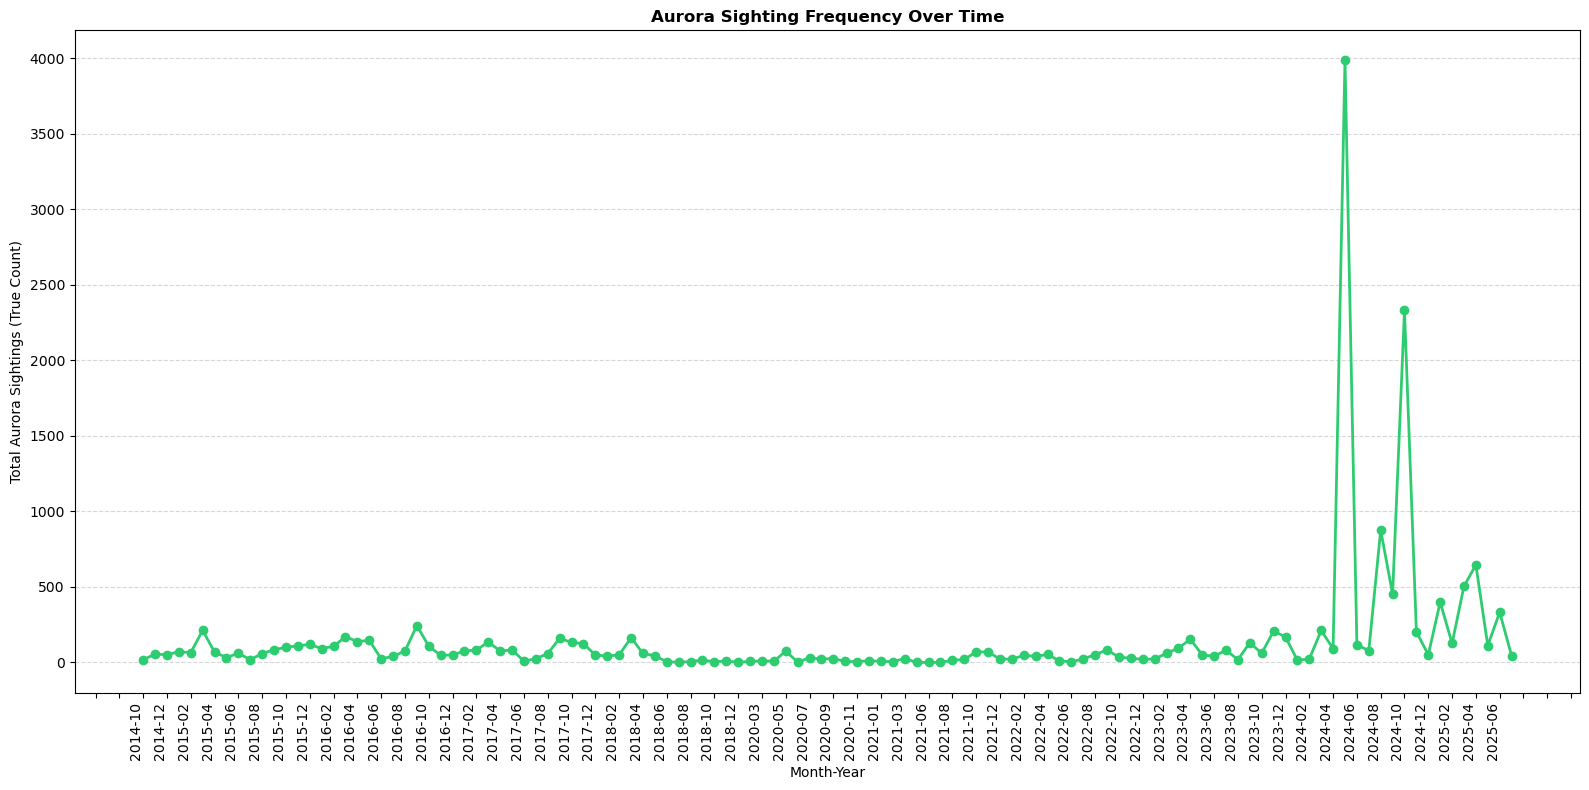

In [80]:
df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed').dt.tz_convert('UTC')
df = df.sort_values('timestamp').reset_index(drop=True)
df['year_month'] = df['timestamp'].dt.tz_localize(None).dt.to_period('M').astype(str)
df['is_aurora_seen'] = df['see_aurora'].astype(int)
monthly_trends = df.groupby('year_month')['is_aurora_seen'].sum().reset_index()

plt.figure(figsize=(16, 8))
plt.plot(monthly_trends['year_month'], monthly_trends['is_aurora_seen'], marker='o', color='#2ecc71', linewidth=2)
plt.xlabel('Month-Year')
plt.ylabel('Total Aurora Sightings (True Count)')
plt.title('Aurora Sighting Frequency Over Time', fontweight='bold')
plt.xticks(rotation=90, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
plt.show()

In [81]:
features_phase1 = ['mlat', 'mlon', 'mlt', 'kp', 'bz_gsm', 'sigma_bz_gsm', 'solar_wind_speed']
df['is_aurora_active'] = df['activities_id'].notna().astype(int)
df[features_phase1].info()

<class 'pandas.DataFrame'>
RangeIndex: 22280 entries, 0 to 22279
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   mlat              22264 non-null  float64
 1   mlon              22264 non-null  float64
 2   mlt               22264 non-null  float64
 3   kp                22280 non-null  float64
 4   bz_gsm            22202 non-null  float64
 5   sigma_bz_gsm      22205 non-null  float64
 6   solar_wind_speed  22280 non-null  float64
dtypes: float64(7)
memory usage: 1.2 MB


In [82]:
df_skim = df.dropna(subset=features_phase1).copy()
df_skim[features_phase1].info()
print(((len(df) - len(df_skim)) / len(df)) * 100)

<class 'pandas.DataFrame'>
Index: 22186 entries, 0 to 22279
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   mlat              22186 non-null  float64
 1   mlon              22186 non-null  float64
 2   mlt               22186 non-null  float64
 3   kp                22186 non-null  float64
 4   bz_gsm            22186 non-null  float64
 5   sigma_bz_gsm      22186 non-null  float64
 6   solar_wind_speed  22186 non-null  float64
dtypes: float64(7)
memory usage: 1.4 MB
0.42190305206463197


In [83]:
df_skim = df_skim.sort_values(by='utc_dt').reset_index(drop=True)

tscv_p1 = TimeSeriesSplit(n_splits=5)

p_activity = np.full(len(df_skim), np.nan)
final_preds = np.full(len(df_skim), np.nan)
valid_test_indices = []

for fold, (train_idx, test_idx) in enumerate(tscv_p1.split(df_skim), 1):
    # re-split train data (80% train, 20% val)
    val_size = int(len(train_idx) * 0.2)
    train_tr_idx = train_idx[:-val_size]
    train_val_idx = train_idx[-val_size:]
    
    X1_train_tr = df_skim.iloc[train_tr_idx][features_phase1]
    y1_train_tr = df_skim.iloc[train_tr_idx]['is_aurora_active']
    
    X1_train_val = df_skim.iloc[train_val_idx][features_phase1]
    y1_train_val = df_skim.iloc[train_val_idx]['is_aurora_active']
    
    X1_test = df_skim.iloc[test_idx][features_phase1]
    y1_test = df_skim.iloc[test_idx]['is_aurora_active']
    
    # Compute scale weight strictly on the sub-training portion
    scale_pos1 = (len(y1_train_tr) - y1_train_tr.sum()) / y1_train_tr.sum()
    
    # Train the model
    model_xgb1 = XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.03, 
                                scale_pos_weight=scale_pos1, random_state=123)
    model_xgb1.fit(X1_train_tr, y1_train_tr)
    
    # Extract probabilities from the out-of-sample validation set and the test set
    val_probs = model_xgb1.predict_proba(X1_train_val)[:, 1]
    test_probs = model_xgb1.predict_proba(X1_test)[:, 1]
    
    p_activity[test_idx] = test_probs
    valid_test_indices.extend(test_idx)
    
    # Find the optimal threshold on validation probabilities
    precisions, recalls, thresholds = precision_recall_curve(y1_train_val, val_probs)
    
    # Protect against division by zero in the F1 score array calculation
    f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
    fold_best_threshold = thresholds[np.argmax(f1_scores)]
    
    # use the new threshold to the unseen test set
    fold_preds = (test_probs >= fold_best_threshold).astype(int)
    final_preds[test_idx] = fold_preds
    
    print(f"\n--- Fold {fold} (Threshold Derived From Validation Window: {fold_best_threshold:.4f}) ---")
    print(confusion_matrix(y1_test, fold_preds))
    print(classification_report(y1_test, fold_preds))

df_skim['p_activity'] = p_activity
df_skim['thresholded_activity_pred'] = final_preds
df_p2 = df_skim.iloc[valid_test_indices].reset_index(drop=True).copy()


--- Fold 1 (Threshold Derived From Validation Window: 0.1750) ---
[[ 648  554]
 [ 210 2285]]
              precision    recall  f1-score   support

           0       0.76      0.54      0.63      1202
           1       0.80      0.92      0.86      2495

    accuracy                           0.79      3697
   macro avg       0.78      0.73      0.74      3697
weighted avg       0.79      0.79      0.78      3697


--- Fold 2 (Threshold Derived From Validation Window: 0.0922) ---
[[  56 1038]
 [  32 2571]]
              precision    recall  f1-score   support

           0       0.64      0.05      0.09      1094
           1       0.71      0.99      0.83      2603

    accuracy                           0.71      3697
   macro avg       0.67      0.52      0.46      3697
weighted avg       0.69      0.71      0.61      3697


--- Fold 3 (Threshold Derived From Validation Window: 0.0385) ---
[[  46 1538]
 [  15 2098]]
              precision    recall  f1-score   support

         

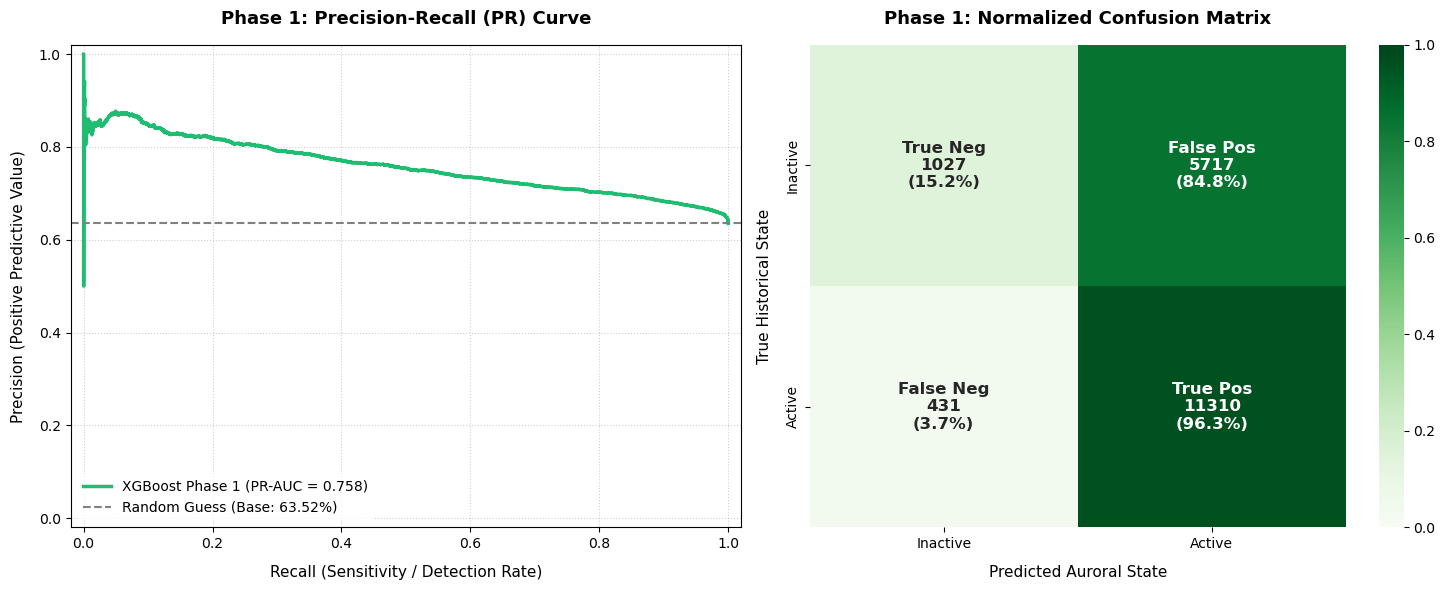

In [84]:
y_true = df_p2['is_aurora_active'].astype(int)
y_probs = df_p2['p_activity']
y_preds = df_p2['thresholded_activity_pred'].astype(int)

precisions, recalls, _ = precision_recall_curve(y_true, y_probs)
pr_auc = auc(recalls, precisions)
baseline_ratio = y_true.sum() / len(y_true) # The proportion of positive cases

cm = confusion_matrix(y_true, y_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# PR Curve 
axes[0].plot(recalls, precisions, color='#1ebd71', lw=2.5, label=f'XGBoost Phase 1 (PR-AUC = {pr_auc:.3f})')
axes[0].axhline(y=baseline_ratio, color='gray', lw=1.5, linestyle='--', label=f'Random Guess (Base: {baseline_ratio:.2%})')
axes[0].set_xlim([-0.02, 1.02])
axes[0].set_ylim([-0.02, 1.02])
axes[0].set_xlabel('Recall (Sensitivity / Detection Rate)', fontsize=11, labelpad=10)
axes[0].set_ylabel('Precision (Positive Predictive Value)', fontsize=11, labelpad=10)
axes[0].set_title('Phase 1: Precision-Recall (PR) Curve', fontsize=13, weight='bold', pad=15)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='lower left', frameon=True, facecolor='white', edgecolor='none')

# Confusion Matrix Heatmap
labels = np.array([
    [f"True Neg\n{cm[0,0]}\n({cm_normalized[0,0]:.1%})", f"False Pos\n{cm[0,1]}\n({cm_normalized[0,1]:.1%})"],
    [f"False Neg\n{cm[1,0]}\n({cm_normalized[1,0]:.1%})", f"True Pos\n{cm[1,1]}\n({cm_normalized[1,1]:.1%})"]
])

sns.heatmap(cm_normalized, annot=labels, fmt="", cmap="Greens", cbar=True,
            xticklabels=['Inactive', 'Active'], yticklabels=['Inactive', 'Active'],
            vmin=0, vmax=1, ax=axes[1], annot_kws={"size": 12, "weight": "bold"})

axes[1].set_xlabel('Predicted Auroral State', fontsize=11, labelpad=10)
axes[1].set_ylabel('True Historical State', fontsize=11, labelpad=10)
axes[1].set_title('Phase 1: Normalized Confusion Matrix', fontsize=13, weight='bold', pad=15)

plt.tight_layout()
plt.show()

II. Second phase: build model for aurora sighting, given aurora activity and weather conditions

In [85]:
features_phase2 = ['p_activity', 'cloud_cover', 'moon_darkness', 'sun_elevation_localtime', 'astronomical_dark_localtime']

## strip out rows with missing data or missing Phase 1 probability estimates
valid_p2_mask = df_p2['p_activity'].notna() & df_p2[features_phase2 + ['is_aurora_seen']].notna().all(axis=1)
df_p2 = df_p2[valid_p2_mask].reset_index(drop=True)

tscv_p2 = TimeSeriesSplit(n_splits=5)
p_seen = np.full(len(df_p2), np.nan)
final_preds2 = np.full(len(df_p2), np.nan)
valid_test_indices2 = []

for fold, (train_idx, test_idx) in enumerate(tscv_p2.split(df_p2), 1):
    # re-split train data (80% train, 20% val)
    val_size = int(len(train_idx) * 0.2)
    train_tr_idx = train_idx[:-val_size]
    train_val_idx = train_idx[-val_size:]
    
    X2_train_tr = df_p2.iloc[train_tr_idx][features_phase2]
    y2_train_tr = df_p2.iloc[train_tr_idx]['is_aurora_seen']
    
    X2_train_val = df_p2.iloc[train_val_idx][features_phase2]
    y2_train_val = df_p2.iloc[train_val_idx]['is_aurora_seen']
    
    X2_test = df_p2.iloc[test_idx][features_phase2]
    y2_test = df_p2.iloc[test_idx]['is_aurora_seen']
    
    # Compute scale weight strictly on the sub-training portion
    scale_pos2 = (len(y2_train_tr) - y2_train_tr.sum()) / y2_train_tr.sum()
    
    # Train the model
    model_xgb2 = XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.03, 
                                scale_pos_weight=scale_pos2, random_state=123)
    model_xgb2.fit(X2_train_tr, y2_train_tr)
    
    # Extract probabilities from the out-of-sample validation set and the test set
    val_probs = model_xgb2.predict_proba(X2_train_val)[:, 1]
    test_probs = model_xgb2.predict_proba(X2_test)[:, 1]
    
    p_seen[test_idx] = test_probs
    valid_test_indices2.extend(test_idx )
    
    precisions, recalls, thresholds = precision_recall_curve(y2_train_val, val_probs)
    
    f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
    fold_best_threshold = thresholds[np.argmax(f1_scores)]
    
    # use the new threshold
    fold_preds = (test_probs >= fold_best_threshold).astype(int)
    final_preds2[test_idx] = fold_preds
    
    print(f"\n--- Fold {fold} (Threshold Derived From Validation Window: {fold_best_threshold:.4f}) ---")
    print(confusion_matrix(y2_test, fold_preds))
    print(classification_report(y2_test, fold_preds))

df_p2['p_seen'] = p_seen
df_p2['thresholded_seen_pred'] = final_preds2
df_final = df_p2.iloc[valid_test_indices2].copy()

# # Strict 80/20 Time Split (Future 20% strictly reserved for final test)
# split = int(len(df_p2) * 0.80)
# X2_train, y2_train = df_p2.iloc[:split][features_phase2], df_p2.iloc[:split]['is_aurora_seen'].astype(int)
# X2_test, y2_test = df_p2.iloc[split:][features_phase2], df_p2.iloc[split:]['is_aurora_seen'].astype(int)

# # Fit Phase 2 Model
# model_xgb2 = XGBClassifier(
#     n_estimators=100, max_depth=4, learning_rate=0.05, random_state=123,
#     scale_pos_weight=(len(y2_train) - y2_train.sum()) / y2_train.sum(),
#     early_stopping_rounds=15, eval_metric="auc", n_jobs=-1
# )
# model_xgb2.fit(X2_train, y2_train, eval_set=[(X2_test, y2_test)], verbose=False)

# # EVALUATION
# probs_xgb2 = model_xgb2.predict_proba(X2_test)[:, 1]
# preds_xgb2 = (probs_xgb2 >= 0.5).astype(int) 

# print("--- Safe Model 2 Metrics ---")
# print(classification_report(y2_test, preds_xgb2))
# print(f"ROC-AUC Score: {roc_auc_score(y2_test, probs_xgb2):.4f}")


--- Fold 1 (Threshold Derived From Validation Window: 0.2305) ---
[[  99  626]
 [  94 2261]]
              precision    recall  f1-score   support

           0       0.51      0.14      0.22       725
           1       0.78      0.96      0.86      2355

    accuracy                           0.77      3080
   macro avg       0.65      0.55      0.54      3080
weighted avg       0.72      0.77      0.71      3080


--- Fold 2 (Threshold Derived From Validation Window: 0.1653) ---
[[  19  920]
 [   3 2138]]
              precision    recall  f1-score   support

           0       0.86      0.02      0.04       939
           1       0.70      1.00      0.82      2141

    accuracy                           0.70      3080
   macro avg       0.78      0.51      0.43      3080
weighted avg       0.75      0.70      0.58      3080


--- Fold 3 (Threshold Derived From Validation Window: 0.1566) ---
[[ 100  875]
 [ 105 2000]]
              precision    recall  f1-score   support

         

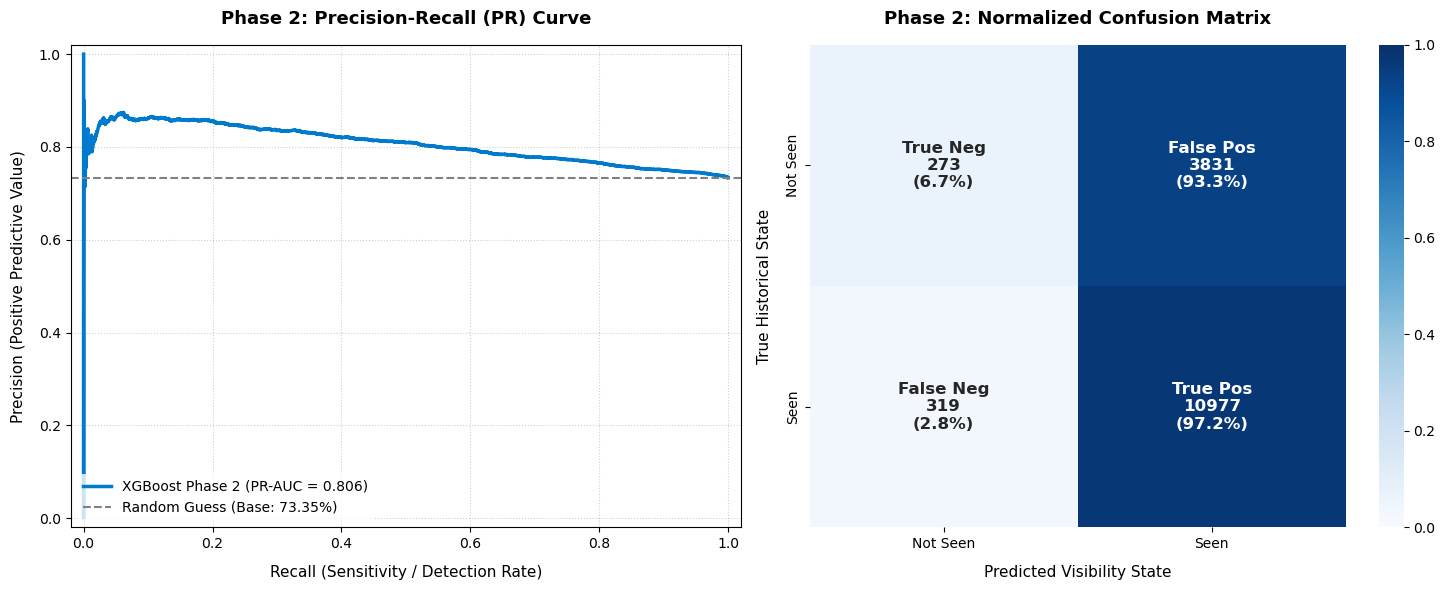

In [86]:
y_true2 = df_final['is_aurora_seen'].astype(int)
y_probs2 = df_final['p_seen']
y_preds2 = df_final['thresholded_seen_pred'].astype(int)

precisions2, recalls2, _ = precision_recall_curve(y_true2, y_probs2)
pr_auc2 = auc(recalls2, precisions2)
baseline_ratio2 = y_true2.sum() / len(y_true2)

cm2 = confusion_matrix(y_true2, y_preds2)
cm_normalized2 = cm2.astype('float') / cm2.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

## PR Curve
axes[0].plot(recalls2, precisions2, color='#007acc', lw=2.5, label=f'XGBoost Phase 2 (PR-AUC = {pr_auc2:.3f})')
axes[0].axhline(y=baseline_ratio2, color='gray', lw=1.5, linestyle='--', label=f'Random Guess (Base: {baseline_ratio2:.2%})')
axes[0].set_xlim([-0.02, 1.02])
axes[0].set_ylim([-0.02, 1.02])
axes[0].set_xlabel('Recall (Sensitivity / Detection Rate)', fontsize=11, labelpad=10)
axes[0].set_ylabel('Precision (Positive Predictive Value)', fontsize=11, labelpad=10)
axes[0].set_title('Phase 2: Precision-Recall (PR) Curve', fontsize=13, weight='bold', pad=15)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='lower left', frameon=True, facecolor='white', edgecolor='none')

## confusion Matrix
labels2 = np.array([
    [f"True Neg\n{cm2[0,0]}\n({cm_normalized2[0,0]:.1%})", f"False Pos\n{cm2[0,1]}\n({cm_normalized2[0,1]:.1%})"],
    [f"False Neg\n{cm2[1,0]}\n({cm_normalized2[1,0]:.1%})", f"True Pos\n{cm2[1,1]}\n({cm_normalized2[1,1]:.1%})"]
])

sns.heatmap(cm_normalized2, annot=labels2, fmt="", cmap="Blues", cbar=True,
            xticklabels=['Not Seen', 'Seen'], yticklabels=['Not Seen', 'Seen'],
            vmin=0, vmax=1, ax=axes[1], annot_kws={"size": 12, "weight": "bold"})

axes[1].set_xlabel('Predicted Visibility State', fontsize=11, labelpad=10)
axes[1].set_ylabel('True Historical State', fontsize=11, labelpad=10)
axes[1].set_title('Phase 2: Normalized Confusion Matrix', fontsize=13, weight='bold', pad=15)

plt.tight_layout()
plt.show()

In [87]:
# Save models after final full-dataset training pass
model_xgb1.get_booster().save_model("models/aurora_physics_m1.json")
model_xgb2.get_booster().save_model("models/aurora_atmosphere_m2.json")

def predict_batch_aurora(df_solar_input, df_weather_input):
    """
    Computes real-time localized aurora sighting probabilities for entire DataFrames.
    Assumes df_solar_input and df_weather_input share a synchronized index or row-order.
    """
    # Load production assets
    m1 = XGBClassifier()
    m2 = XGBClassifier()
    m1.load_model("aurora_physics_m1.json")
    m2.load_model("aurora_atmosphere_m2.json")
    
    # Explicitly lock feature ordering to match training matrices exactly
    features_p1 = ['mlat', 'mlon', 'mlt', 'kp', 'bz_gsm', 'sigma_bz_gsm', 'solar_wind_speed']
    features_p2 = ['p_activity', 'cloud_cover', 'moon_darkness', 'sun_elevation_localtime', 'astronomical_dark_localtime']
    
    X1 = df_solar_input[features_p1].copy()
    p_activity = m1.predict_proba(X1)[:, 1]
    
    X2 = df_weather_input.copy()
    X2['p_activity'] = p_activity
    X2 = X2[features_p2]
    p_seen = m2.predict_proba(X2)[:, 1]
    
    # joint probability
    final_score = p_activity * p_seen
    
    df_results = pd.DataFrame({
        'prob_activity_overhead': p_activity,
        'prob_clear_conditions': p_seen,
        'final_sighting_probability': final_score
    }, index=df_solar_input.index) # Preserve original row mapping index
    
    return df_results